In [ ]:
# 1. Instalación limpia de la librería oficial de Ultralytics
!pip install ultralytics -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 30.4 MB/s eta 0:00:00


In [ ]:
# =====================================================================
# DIVIDIR DATASET LOCAL EN TRAIN/VAL (EN MEMORIA COLAB)
# =====================================================================

import os
import shutil
from sklearn.model_selection import train_test_split
from google.colab import drive
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms, models
from tqdm import tqdm
from PIL import Image
import cv2
import numpy as np
from PIL import Image
from ultralytics import YOLO
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import random
# Montar Drive
drive.mount('/content/drive')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Mounted at /content/drive


In [ ]:

# =====================================================================
# 1. RUTAS
# =====================================================================

RUTA_IMAGES = "/content/drive/MyDrive/TFM_Pipeline/Dataset_local/Dataset_60_40_binario/images/train"
RUTA_LABELS = "/content/drive/MyDrive/TFM_Pipeline/Dataset_local/Dataset_60_40_binario/labels/train"

RUTA_DESTINO = "/content/dataset_local"





In [ ]:
# =====================================================================
# 2. VERIFICAR
# =====================================================================

print("🔍 Verificando dataset...")

if not os.path.exists(RUTA_IMAGES):
    print(f"❌ Ruta de imágenes no encontrada: {RUTA_IMAGES}")
    exit()

if not os.path.exists(RUTA_LABELS):
    print(f"❌ Ruta de etiquetas no encontrada: {RUTA_LABELS}")
    exit()

print("✅ Rutas encontradas")

# Contar imágenes
imagenes = [f for f in os.listdir(RUTA_IMAGES)
           if f.endswith(('.jpg','.jpeg','.png'))]
print(f"📸 Imágenes: {len(imagenes)}")

# Contar etiquetas
etiquetas = [f for f in os.listdir(RUTA_LABELS)
            if f.endswith('.txt')]
print(f"📝 Etiquetas: {len(etiquetas)}")

# Verificar correspondencia
nombres_img = set([os.path.splitext(f)[0] for f in imagenes])
nombres_txt = set([os.path.splitext(f)[0] for f in etiquetas])
coinciden = nombres_img & nombres_txt
print(f"✅ Coinciden: {len(coinciden)} imágenes con etiqueta")

🔍 Verificando dataset...
✅ Rutas encontradas
📸 Imágenes: 163
📝 Etiquetas: 163
✅ Coinciden: 163 imágenes con etiqueta


In [ ]:

# =====================================================================
# 3. CREAR ESTRUCTURA EN MEMORIA
# =====================================================================

print("\n📂 Creando estructura en /content...")

for split in ['train', 'val']:
    for sub in ['images', 'labels']:
        os.makedirs(os.path.join(RUTA_DESTINO, split, sub), exist_ok=True)

# =====================================================================
# 4. DIVIDIR POR IMAGEN (80/20)
# =====================================================================

print("\n📊 Dividiendo en train/val (80/20)...")

# Obtener imágenes con etiqueta
imagenes_validas = [f for f in imagenes
                   if os.path.splitext(f)[0] in coinciden]

if len(imagenes_validas) == 0:
    print("❌ No hay imágenes con etiquetas correspondientes")
    exit()

# Dividir 80/20
idx_train, idx_val = train_test_split(
    range(len(imagenes_validas)),
    test_size=0.2,
    random_state=42
)

# Copiar archivos
for split, indices in [('train', idx_train), ('val', idx_val)]:
    for i in indices:
        archivo = imagenes_validas[i]
        nombre_base = os.path.splitext(archivo)[0]

        # Copiar imagen
        shutil.copy2(
            os.path.join(RUTA_IMAGES, archivo),
            os.path.join(RUTA_DESTINO, split, 'images', archivo)
        )

        # Copiar etiqueta
        txt_file = f"{nombre_base}.txt"
        if os.path.exists(os.path.join(RUTA_LABELS, txt_file)):
            shutil.copy2(
                os.path.join(RUTA_LABELS, txt_file),
                os.path.join(RUTA_DESTINO, split, 'labels', txt_file)
            )

print(f"   Train: {len(idx_train)} imágenes")
print(f"   Val: {len(idx_val)} imágenes")

# =====================================================================
# 5. VERIFICAR RESULTADO
# =====================================================================

print("\n" + "="*50)
print("✅ DATASET LISTO EN MEMORIA")
print("="*50)

for split in ['train', 'val']:
    print(f"\n📁 {split.upper()}:")
    ruta_img = os.path.join(RUTA_DESTINO, split, 'images')
    ruta_lab = os.path.join(RUTA_DESTINO, split, 'labels')

    if os.path.exists(ruta_img):
        count = len([f for f in os.listdir(ruta_img)
                    if f.endswith(('.jpg','.jpeg','.png'))])
        print(f"   Imágenes: {count}")
    if os.path.exists(ruta_lab):
        count = len([f for f in os.listdir(ruta_lab)
                    if f.endswith('.txt')])
        print(f"   Etiquetas: {count}")

print(f"\n📂 Ruta: {RUTA_DESTINO}")
print("\n✅ Listo para fine-tuning")




📂 Creando estructura en /content...

📊 Dividiendo en train/val (80/20)...
   Train: 130 imágenes
   Val: 33 imágenes

✅ DATASET LISTO EN MEMORIA

📁 TRAIN:
   Imágenes: 130
   Etiquetas: 130

📁 VAL:
   Imágenes: 33
   Etiquetas: 33

📂 Ruta: /content/dataset_local

✅ Listo para fine-tuning


In [ ]:
print(os.listdir("/content/drive/MyDrive//TFM_Pipeline/Dataset_local/Dataset_60_40_binario/images/train/0_sano"))

[]


In [ ]:
# =====================================================================
# EXPERIMENTO 5: FINE-TUNING CON DATASET LOCAL (TRAIN/VAL)
# =====================================================================



# =====================================================================
# 1. CONFIGURACIÓN
# =====================================================================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️ Dispositivo: {device}")

# Rutas
RUTA_LOCAL = RUTA_DESTINO  # Dataset preparado (train/val)
RUTA_DRIVE = "/content/drive/MyDrive/TFM_Pipeline/Pesos_Modelos"

PATH_PESOS_BASE = os.path.join(RUTA_DRIVE, "exp4_recortes_yolo_mejor.pth")
PATH_SALIDA = os.path.join(RUTA_DRIVE, "exp5_resnet50_cbam_finetuning.pth")



🖥️ Dispositivo: cuda


In [ ]:
# =====================================================================
# 2. DATASET PERSONALIZADO
# =====================================================================

class DatasetYOLO(Dataset):
    def __init__(self, root, transform=None):
        self.root = root
        self.transform = transform
        self.img_dir = os.path.join(root, 'images')
        self.lab_dir = os.path.join(root, 'labels')

        self.imagenes = []
        for f in os.listdir(self.img_dir):
            if f.endswith(('.jpg','.jpeg','.png')):
                nombre_base = os.path.splitext(f)[0]
                if os.path.exists(os.path.join(self.lab_dir, f"{nombre_base}.txt")):
                    self.imagenes.append(f)

    def __len__(self):
        return len(self.imagenes)

    def __getitem__(self, idx):
        nombre_img = self.imagenes[idx]
        nombre_base = os.path.splitext(nombre_img)[0]

        # Cargar imagen
        img_path = os.path.join(self.img_dir, nombre_img)
        imagen = Image.open(img_path).convert('RGB')

        # Leer etiquetas
        txt_path = os.path.join(self.lab_dir, f"{nombre_base}.txt")
        clase = 0  # Default: sano
        if os.path.exists(txt_path):
            with open(txt_path, 'r') as f:
                for linea in f:
                    partes = linea.strip().split()
                    if len(partes) >= 1:
                        try:
                            if int(float(partes[0])) == 1:
                                clase = 1  # Enfermo
                                break
                        except:
                            continue

        if self.transform:
            imagen = self.transform(imagen)

        return imagen, clase

In [ ]:
# =====================================================================
# 2. TRANSFORMACIONES
# =====================================================================

class ResizeWithPadding:
    def __init__(self, size=224):
        self.size = size

    def __call__(self, img):
        from torchvision.transforms import functional as F
        w, h = img.size
        escala = self.size / max(w, h)
        nuevo_w = int(w * escala)
        nuevo_h = int(h * escala)
        img_redim = F.resize(img, (nuevo_h, nuevo_w))
        pad_izq = (self.size - nuevo_w) // 2
        pad_der = self.size - nuevo_w - pad_izq
        pad_sup = (self.size - nuevo_h) // 2
        pad_inf = self.size - nuevo_h - pad_sup
        return F.pad(img_redim, (pad_izq, pad_sup, pad_der, pad_inf), fill=0)




In [ ]:
transform_train = transforms.Compose([
    ResizeWithPadding(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_val = transforms.Compose([
    ResizeWithPadding(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [ ]:
# =====================================================================
# 3. DATALOADERS
# =====================================================================

dataset_train = DatasetYOLO(
    root=os.path.join(RUTA_LOCAL, 'train'),
    transform=transform_train
)

dataset_val = DatasetYOLO(
    root=os.path.join(RUTA_LOCAL, 'val'),
    transform=transform_val
)

train_loader = DataLoader(dataset_train, batch_size=8, shuffle=True, num_workers=2)
val_loader = DataLoader(dataset_val, batch_size=8, shuffle=False, num_workers=2)

print(f"📊 Train: {len(dataset_train)} imágenes")
print(f"📊 Val: {len(dataset_val)} imágenes")

📊 Train: 130 imágenes
📊 Val: 33 imágenes


In [ ]:
# =====================================================================
# 4. MODELO
# =====================================================================

#Definición del Módulo de Atención Convolucional (CBAM)
class CBAM(nn.Module):
    def __init__(self, canales_entrada, ratio_reduccion=16):
        super(CBAM, self).__init__()
        # Atención de Canal (Channel Attention)
        self.mlp = nn.Sequential(
            nn.Flatten(),
            nn.Linear(canales_entrada, canales_entrada // ratio_reduccion, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(canales_entrada // ratio_reduccion, canales_entrada, bias=False)
        )
        self.sigmoid_canal = nn.Sigmoid()

        # Atención Espacial (Spatial Attention)
        self.conv_espacial = nn.Conv2d(2, 1, kernel_size=7, padding=3, bias=False)
        self.sigmoid_espacial = nn.Sigmoid()

    def forward(self, x):
        # Flujo de Canal (¿Qué patrones morfológicos importan?)
        avg_out = self.mlp(nn.functional.adaptive_avg_pool2d(x, (1, 1)))
        max_out = self.mlp(nn.functional.adaptive_max_pool2d(x, (1, 1)))
        atencion_canal = self.sigmoid_canal(avg_out + max_out).unsqueeze(2).unsqueeze(3)
        x = x * atencion_canal

        # Flujo Espacial (¿En qué coordenadas de la mazorca están?)
        avg_out_e = torch.mean(x, dim=1, keepdim=True)
        max_out_e, _ = torch.max(x, dim=1, keepdim=True)
        atencion_espacial = self.sigmoid_espacial(self.conv_espacial(torch.cat([avg_out_e, max_out_e], dim=1)))
        return x * atencion_espacial

# 2. Ensamblado de la Red Híbrida Adaptativa para el TFM
class ResNet50_CBAM(nn.Module):
    def __init__(self):
        super(ResNet50_CBAM, self).__init__()
        # Compatibilidad con versiones modernas de Torchvision
        try:
            resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        except:
            resnet = models.resnet50(pretrained=True)

        # Congelamos las primeras etapas de extracción genérica (bloques 1, 2 y 3)
        for param in resnet.parameters():
            param.requires_grad = False

        self.features_congeladas = nn.Sequential(
            resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool,
            resnet.layer1, resnet.layer2, resnet.layer3
        )

        # Descongelamos la capa profunda convolucional (layer4)
        self.layer4 = resnet.layer4
        for param in self.layer4.parameters():
            param.requires_grad = True

        # Módulo de atención y Clasificador entrenados desde cero
        self.cbam = CBAM(canales_entrada=2048)
        self.avgpool = resnet.avgpool
        self.fc = nn.Linear(resnet.fc.in_features, 2)

    def forward(self, x):
        x = self.features_congeladas(x)
        x = self.layer4(x)
        x = self.cbam(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)

In [ ]:
# =====================================================================
# 6. ENTRENAMIENTO CON VALIDACIÓN
# =====================================================================

modelo = ResNet50_CBAM().to(device)

# Cargar pesos
if os.path.exists(PATH_PESOS_BASE):
    modelo.load_state_dict(torch.load(PATH_PESOS_BASE, map_location=device))
    print("✅ Pesos base cargados")

# Congelar
for param in modelo.features_congeladas.parameters():
    param.requires_grad = False

for param in modelo.layer4.parameters():
    param.requires_grad = True
for param in modelo.cbam.parameters():
    param.requires_grad = True
for param in modelo.fc.parameters():
    param.requires_grad = True

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, modelo.parameters()),
    lr=1e-5,
    weight_decay=1e-4
)

EPOCHS = 30
mejor_acc = 0.0
mejor_val_loss = float('inf')
paciencia = 7
contador_paciencia = 0
print("\n🚀 Iniciando Fine-Tuning...")

for epoch in range(EPOCHS):
    # Train
    modelo.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for imagenes, etiquetas in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]"):
        imagenes, etiquetas = imagenes.to(device), etiquetas.to(device)

        optimizer.zero_grad()
        outputs = modelo(imagenes)
        loss = criterion(outputs, etiquetas)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * imagenes.size(0)
        _, preds = torch.max(outputs, 1)
        train_correct += (preds == etiquetas).sum().item()
        train_total += etiquetas.size(0)

    train_loss = train_loss / train_total
    train_acc = 100 * train_correct / train_total

    # Val
    modelo.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for imagenes, etiquetas in val_loader:
            imagenes, etiquetas = imagenes.to(device), etiquetas.to(device)
            outputs = modelo(imagenes)
            loss = criterion(outputs, etiquetas)

            val_loss += loss.item() * imagenes.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == etiquetas).sum().item()
            val_total += etiquetas.size(0)

    val_loss = val_loss / val_total
    val_acc = 100 * val_correct / val_total

    print(f"📊 Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"   Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    if val_acc > mejor_acc:
        mejor_acc = val_acc
        torch.save(modelo.state_dict(), "mejor_modelo_ecuador.pth")
        print(f"💾 Mejor modelo (Val Acc: {mejor_acc:.2f}%)")
        # Early Stopping basado en val_loss
    if val_loss < mejor_val_loss:
        mejor_val_loss = val_loss
        contador_paciencia = 0
    else:
        contador_paciencia += 1
        print(f"⏳ Early Stopping: {contador_paciencia}/{paciencia}")

    if contador_paciencia >= paciencia:
        print(f"\n🛑 Early Stopping activado en la época {epoch+1}")
        break

    print("-" * 50)

# Guardar
modelo.load_state_dict(torch.load("mejor_modelo_ecuador.pth"))
torch.save(modelo.state_dict(), PATH_SALIDA)
print(f"\n💾 Modelo guardado en: {PATH_SALIDA}")
print(f"🎯 Mejor Accuracy en Validación: {mejor_acc:.2f}%")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 122MB/s]


✅ Pesos base cargados

🚀 Iniciando Fine-Tuning...


Epoch 1/30 [Train]: 100%|██████████| 17/17 [00:16<00:00,  1.05it/s]


📊 Train Loss: 1.5574 | Train Acc: 57.69%
   Val Loss: 1.5763 | Val Acc: 51.52%
💾 Mejor modelo (Val Acc: 51.52%)
--------------------------------------------------


...

📊 Train Loss: 0.3635 | Train Acc: 83.85%
   Val Loss: 0.4696 | Val Acc: 75.76%
💾 Mejor modelo (Val Acc: 75.76%)
⏳ Early Stopping: 1/7
--------------------------------------------------


Epoch 29/30 [Train]: 100%|██████████| 17/17 [00:15<00:00,  1.12it/s]


📊 Train Loss: 0.4282 | Train Acc: 74.62%
   Val Loss: 0.4410 | Val Acc: 66.67%
--------------------------------------------------


Epoch 30/30 [Train]: 100%|██████████| 17/17 [00:15<00:00,  1.11it/s]


📊 Train Loss: 0.3901 | Train Acc: 84.62%
   Val Loss: 0.4683 | Val Acc: 72.73%
⏳ Early Stopping: 1/7
--------------------------------------------------

💾 Modelo guardado en: /content/drive/MyDrive/TFM_Pipeline/Pesos_Modelos/exp5_resnet50_cbam_finetuning.pth
🎯 Mejor Accuracy en Validación: 75.76%


In [ ]:
# =====================================================================
# EVALUACIÓN DEL PIPELINE EN CASCADA (YOLO + RESNET50_CBAM)
# =====================================================================
# Propósito: Evaluar el modelo fine-tuned (Experimento 5) en dataset local
# =====================================================================


# =====================================================================
# 3. FUNCIONES AUXILIARES
# =====================================================================

def calcular_iou(boxA, boxB):
    """Calcula Intersección sobre Unión entre dos cajas [x1,y1,x2,y2]"""
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    inter = max(0, xB - xA) * max(0, yB - yA)
    areaA = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    areaB = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    union = areaA + areaB - inter

    return inter / union if union > 0 else 0

def leer_etiquetas_yolo(txt_path, img_w, img_h):
    """Convierte etiquetas YOLO (normalizadas) a coordenadas en píxeles"""
    cajas = []
    if not os.path.exists(txt_path):
        return cajas

    with open(txt_path, 'r') as f:
        for linea in f:
            partes = linea.strip().split()
            if len(partes) == 5:
                clase = int(partes[0])
                x_c, y_c, w_n, h_n = map(float, partes[1:])
                x1 = int((x_c - w_n/2) * img_w)
                y1 = int((y_c - h_n/2) * img_h)
                x2 = int((x_c + w_n/2) * img_w)
                y2 = int((y_c + h_n/2) * img_h)
                cajas.append({"clase": clase, "box": [x1, y1, x2, y2]})
    return cajas



In [ ]:
# =====================================================================
# 4. CONFIGURACIÓN
# =====================================================================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️ Dispositivo: {device}")

# Rutas
PATH_YOLO = "/content/drive/MyDrive/TFM_Pipeline/YOLO_Resultados/yolo_exp4-2/weights/best.pt"
PATH_RESNET = "/content/drive/MyDrive/TFM_Pipeline/Pesos_Modelos/exp5_resnet50_cbam_finetuning.pth"

RUTA_TEST = "/content/drive/MyDrive/TFM_Pipeline/Dataset_local/Dataset_60_40_binario/images/test"
RUTA_LABELS = "/content/drive/MyDrive/TFM_Pipeline/Dataset_local/Dataset_60_40_binario/labels/test"

# =====================================================================
# 5. CARGAR MODELOS
# =====================================================================

print("📦 Cargando YOLO...")
modelo_yolo = YOLO(PATH_YOLO)

print("📦 Cargando ResNet50 + CBAM (Experimento 5)...")
modelo_resnet = ResNet50_CBAM().to(device)
modelo_resnet.load_state_dict(torch.load(PATH_RESNET, map_location=device))
modelo_resnet.eval()

# Transformaciones
resize_padding = ResizeWithPadding(224)
transform_resnet = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


🖥️ Dispositivo: cuda
📦 Cargando YOLO...
📦 Cargando ResNet50 + CBAM (Experimento 5)...


In [ ]:

# =====================================================================
# 6. EVALUACIÓN EN TEST
# =====================================================================

print("\n🧪 Evaluando pipeline en cascada (YOLO + ResNet50_CBAM)...")

y_true, y_pred = [], []
extensiones = ('.png', '.jpg', '.jpeg', '.JPG', '.JPEG', '.PNG')

if not os.path.exists(RUTA_TEST):
    print(f"❌ Ruta no encontrada: {RUTA_TEST}")
    exit()

for carpeta in ["0_sano", "1_enfermo"]:
    ruta_clase = os.path.join(RUTA_TEST, carpeta)
    if not os.path.exists(ruta_clase):
        continue

    archivos = [f for f in os.listdir(ruta_clase) if f.endswith(extensiones)]

    for archivo in archivos:
        # Cargar imagen
        img_path = os.path.join(ruta_clase, archivo)
        img = cv2.imread(img_path)
        if img is None:
            continue

        h, w, _ = img.shape
        nombre_base = os.path.splitext(archivo)[0]

        # Leer ground truth
        txt_path = os.path.join(RUTA_LABELS, f"{nombre_base}.txt")
        cajas_reales = leer_etiquetas_yolo(txt_path, w, h)

        if not cajas_reales:
            continue

        # Detectar con YOLO
        resultados = modelo_yolo(img, verbose=False)[0]

        if len(resultados.boxes) == 0:
            continue

        # Procesar cada detección
        for box_yolo in resultados.boxes:
            x1, y1, x2, y2 = map(int, box_yolo.xyxy[0].tolist())
            x1, y1 = max(0, x1), max(0, y1)
            x2, y2 = min(w, x2), min(h, y2)

            # Buscar mejor coincidencia con ground truth
            mejor_iou = 0.0
            clase_real = -1

            for gt in cajas_reales:
                iou = calcular_iou([x1, y1, x2, y2], gt["box"])
                if iou > mejor_iou:
                    mejor_iou = iou
                    clase_real = gt["clase"]

            # Umbral IoU: ignorar detecciones sin coincidencia
            if mejor_iou < 0.3:
                continue

            # Clasificar con ResNet
            recorte = img[y1:y2, x1:x2]
            if recorte.size == 0:
                continue

            recorte_rgb = cv2.cvtColor(recorte, cv2.COLOR_BGR2RGB)
            pil_img = Image.fromarray(recorte_rgb)

            # Preprocesar
            img_padded = resize_padding(pil_img)
            img_tensor = transform_resnet(img_padded).unsqueeze(0).to(device)

            # Inferencia
            with torch.no_grad():
                output = modelo_resnet(img_tensor)
                _, pred = torch.max(output, 1)
                clase_predicha = pred.item()

            # Guardar
            y_true.append(clase_real)
            y_pred.append(clase_predicha)




🧪 Evaluando pipeline en cascada (YOLO + ResNet50_CBAM)...



📊 RESULTADOS DEL PIPELINE EN CASCADA (EXPERIMENTO 5)
🔢 Total de mazorcas evaluadas: 91
🎯 Accuracy: 84.62%

📋 Reporte de Clasificación:
              precision    recall  f1-score   support

        Sano       0.70      0.85      0.77        27
     Enfermo       0.93      0.84      0.89        64

    accuracy                           0.85        91
   macro avg       0.81      0.85      0.83        91
weighted avg       0.86      0.85      0.85        91



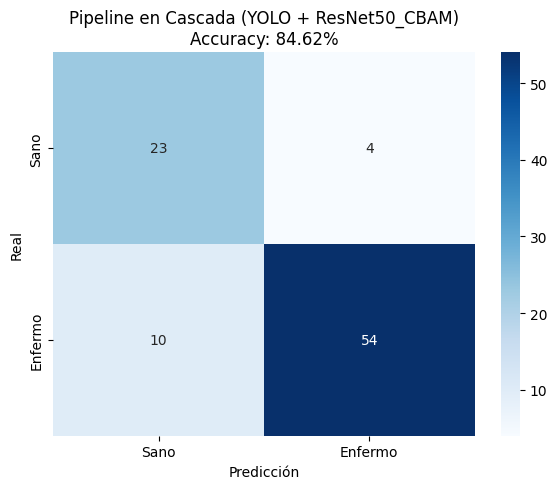

In [ ]:
# =====================================================================
# 7. RESULTADOS
# =====================================================================

print("\n" + "="*60)
print("📊 RESULTADOS DEL PIPELINE EN CASCADA (EXPERIMENTO 5)")
print("="*60)

if len(y_true) == 0:
    print("⚠️ No se evaluaron instancias. Verifica rutas.")
else:
    print(f"🔢 Total de mazorcas evaluadas: {len(y_true)}")

    acc = accuracy_score(y_true, y_pred)
    print(f"🎯 Accuracy: {acc * 100:.2f}%")

    print("\n📋 Reporte de Clasificación:")
    print(classification_report(y_true, y_pred, target_names=["Sano", "Enfermo"]))

    # Matriz de confusión
    plt.figure(figsize=(6, 5))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
                xticklabels=["Sano", "Enfermo"],
                yticklabels=["Sano", "Enfermo"])
    plt.title(f"Pipeline en Cascada (YOLO + ResNet50_CBAM)\nAccuracy: {acc*100:.2f}%")
    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.tight_layout()
    plt.show()

🖥️ Dispositivo: cuda
📦 Cargando modelos...
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 175MB/s]



📸 Procesando 3 imágenes...

Imagen 1: grave_10.jpeg
⚠️ No se detectaron mazorcas en /content/drive/MyDrive/TFM_Pipeline/Dataset_local/Dataset_60_40_binario/images/test/1_enfermo/grave_10.jpeg
⚠️ No se pudo procesar /content/drive/MyDrive/TFM_Pipeline/Dataset_local/Dataset_60_40_binario/images/test/1_enfermo/grave_10.jpeg

Imagen 2: sano_45.jpg


sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


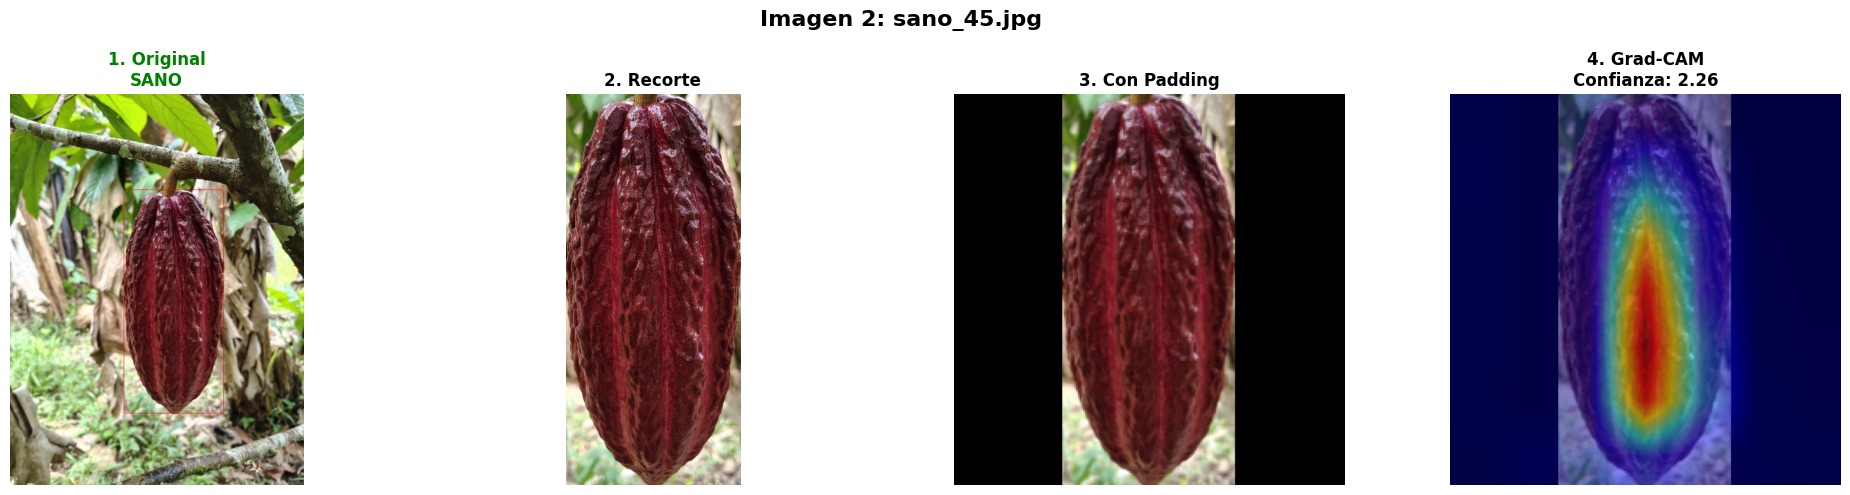


Imagen 3: sano_27.jpg


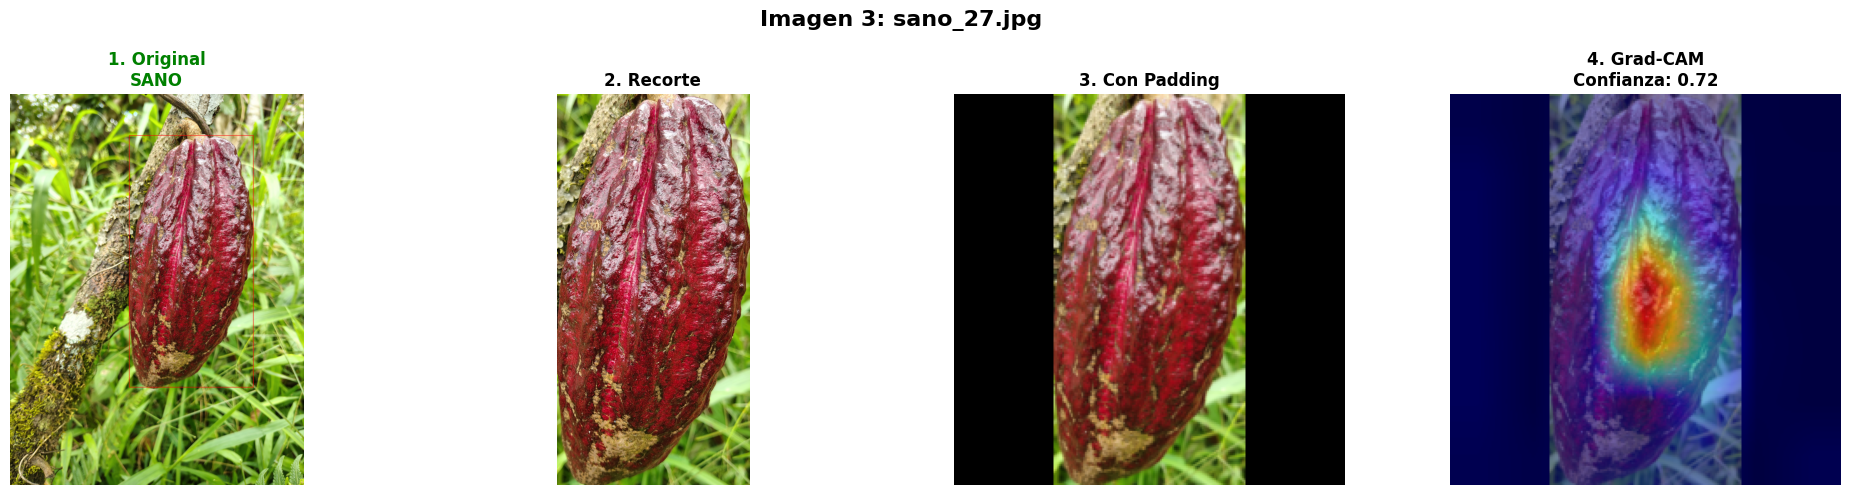


✅ Visualización Grad-CAM completada


In [ ]:
# =====================================================================
# VISUALIZACIÓN GRAD-CAM: IMAGEN ORIGINAL + RECORTE + PADDING + HEATMAP
# =====================================================================

import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image, ImageDraw
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

# =====================================================================
# 1. FUNCIONES PARA GRAD-CAM
# =====================================================================

class GradCAM:
    def __init__(self, modelo, capa_objetivo):
        self.modelo = modelo
        self.capa_objetivo = capa_objetivo
        self.gradientes = None
        self.activaciones = None

        # Registrar hooks
        self._registrar_hooks()

    def _registrar_hooks(self):
        def hook_grad(module, grad_in, grad_out):
            self.gradientes = grad_out[0]

        def hook_act(module, input, output):
            self.activaciones = output

        self.capa_objetivo.register_forward_hook(hook_act)
        self.capa_objetivo.register_full_backward_hook(hook_grad)

    def generar_cam(self, input_tensor, clase_idx=None):
        """Genera el mapa de activación Grad-CAM"""
        self.modelo.zero_grad()
        output = self.modelo(input_tensor)

        if clase_idx is None:
            clase_idx = torch.argmax(output, dim=1).item()

        # Backward de la clase
        score = output[0, clase_idx]
        score.backward()

        # Calcular Grad-CAM
        grads = self.gradientes.cpu().data.numpy()[0]
        acts = self.activaciones.cpu().data.numpy()[0]

        pesos = np.mean(grads, axis=(1, 2))
        cam = np.zeros(acts.shape[1:], dtype=np.float32)

        for i, w in enumerate(pesos):
            cam += w * acts[i, :, :]

        cam = np.maximum(cam, 0)
        if np.max(cam) > 0:
            cam = cam / np.max(cam)

        return cam, clase_idx, output[0, clase_idx].item()

# =====================================================================
# 2. PROCESAR UNA IMAGEN PARA VISUALIZACIÓN
# =====================================================================

def procesar_imagen_gradcam(img_path, modelo_yolo, modelo_resnet, resize_padding, transform_resnet, device):
    """
    Procesa una imagen y genera las 4 visualizaciones:
    1. Imagen original con detección YOLO
    2. Recorte de la mazorca
    3. Recorte con padding (entrada del modelo)
    4. Grad-CAM superpuesto
    """

    # Leer imagen
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        return None

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w, _ = img_bgr.shape

    # Detectar con YOLO
    resultados = modelo_yolo(img_bgr, verbose=False)[0]

    if len(resultados.boxes) == 0:
        print(f"⚠️ No se detectaron mazorcas en {img_path}")
        return None

    # Tomar la primera detección
    box = resultados.boxes[0]
    x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(w, x2), min(h, y2)

    # 1. Imagen original con bounding box
    img_original = img_rgb.copy()
    cv2.rectangle(img_original, (x1, y1), (x2, y2), (255, 0, 0), 3)

    # 2. Recorte de la mazorca
    recorte = img_rgb[y1:y2, x1:x2]

    # 3. Recorte con padding (entrada del modelo)
    pil_recorte = Image.fromarray(recorte)
    img_padded = resize_padding(pil_recorte)
    img_padded_np = np.array(img_padded)

    # 4. Grad-CAM
    input_tensor = transform_resnet(img_padded).unsqueeze(0).to(device)

    # Crear GradCAM
    grad_cam = GradCAM(modelo_resnet, modelo_resnet.layer4)
    cam, clase_pred, confianza = grad_cam.generar_cam(input_tensor)

    # Redimensionar CAM al tamaño del recorte con padding
    cam_resized = cv2.resize(cam, (img_padded_np.shape[1], img_padded_np.shape[0]))

    # Superponer heatmap
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    img_padded_float = img_padded_np.astype(np.float32) / 255.0
    heatmap_float = heatmap.astype(np.float32) / 255.0

    # Superposición
    overlay = cv2.addWeighted(img_padded_float, 0.5, heatmap_float, 0.5, 0)

    # Diagnóstico
    nombre_clase = "ENFERMO" if clase_pred == 1 else "SANO"
    color = "red" if clase_pred == 1 else "green"

    return {
        'imagen_original': img_original,
        'recorte': recorte,
        'padded': img_padded_np,
        'gradcam': overlay,
        'clase': nombre_clase,
        'confianza': confianza,
        'color': color
    }

# =====================================================================
# 3. VISUALIZAR RESULTADOS
# =====================================================================

def visualizar_gradcam(resultados, titulo="Grad-CAM"):
    """Muestra las 4 visualizaciones en una fila"""

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    # Títulos
    titulos = [
        f"1. Original\n{resultados['clase']}",
        "2. Recorte",
        "3. Con Padding",
        f"4. Grad-CAM\nConfianza: {resultados['confianza']:.2f}"
    ]

    # Imágenes
    imagenes = [
        resultados['imagen_original'],
        resultados['recorte'],
        resultados['padded'],
        resultados['gradcam']
    ]

    for i, (ax, img, tit) in enumerate(zip(axes, imagenes, titulos)):
        ax.imshow(img)
        ax.set_title(tit, fontsize=12, fontweight='bold')
        ax.axis('off')

        # Color del título según diagnóstico
        if i == 0:
            color = resultados['color']
            ax.set_title(tit, fontsize=12, fontweight='bold', color=color)

    plt.suptitle(titulo, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# =====================================================================
# 4. EJECUCIÓN PRINCIPAL
# =====================================================================

# Configuración
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️ Dispositivo: {device}")

# Rutas (AJUSTA SEGÚN TUS RUTAS)
PATH_YOLO = "/content/drive/MyDrive/TFM_Pipeline/YOLO_Resultados/yolo_exp4-2/weights/best.pt"
PATH_RESNET = "/content/drive/MyDrive/TFM_Pipeline/Pesos_Modelos/exp5_resnet50_cbam_finetuning.pth"

# Cargar modelos
print("📦 Cargando modelos...")
modelo_yolo = YOLO(PATH_YOLO)

modelo_resnet = ResNet50_CBAM().to(device)
modelo_resnet.load_state_dict(torch.load(PATH_RESNET, map_location=device))
modelo_resnet.eval()

# Transformaciones
resize_padding = ResizeWithPadding(224)
transform_resnet = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# =====================================================================
# 5. SELECCIONAR 3 IMÁGENES ALEATORIAS DEL TEST
# =====================================================================



RUTA_TEST = "/content/drive/MyDrive/TFM_Pipeline/Dataset_local/Dataset_60_40_binario/images/test"

# Recolectar imágenes
imagenes_test = []
for carpeta in ["0_sano", "1_enfermo"]:
    ruta = os.path.join(RUTA_TEST, carpeta)
    if os.path.exists(ruta):
        for archivo in os.listdir(ruta):
            if archivo.endswith(('.jpg', '.jpeg', '.png')):
                imagenes_test.append(os.path.join(ruta, archivo))

# Seleccionar 3 aleatorias
if len(imagenes_test) >= 3:
    seleccionadas = random.sample(imagenes_test, 3)
else:
    seleccionadas = imagenes_test[:min(3, len(imagenes_test))]

print(f"\n📸 Procesando {len(seleccionadas)} imágenes...")

# Procesar cada imagen
for i, img_path in enumerate(seleccionadas):
    print(f"\n{'='*60}")
    print(f"Imagen {i+1}: {os.path.basename(img_path)}")

    resultado = procesar_imagen_gradcam(
        img_path, modelo_yolo, modelo_resnet,
        resize_padding, transform_resnet, device
    )

    if resultado:
        visualizar_gradcam(resultado, f"Imagen {i+1}: {os.path.basename(img_path)}")
    else:
        print(f"⚠️ No se pudo procesar {img_path}")

print("\n✅ Visualización Grad-CAM completada")

In [ ]:
# =====================================================================
# PIPELINE EN CASCADA: YOLO + RESNET50_CBAM (EXPERIMENTO 5)
# =====================================================================
# Propósito: Cargar imagen local, detectar mazorcas con YOLO,
# clasificar cada una con ResNet50_CBAM y visualizar Grad-CAM
# =====================================================================

import os
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from google.colab import files



# =====================================================================
# 3. GRAD-CAM
# =====================================================================

class GradCAM:
    def __init__(self, modelo, capa_objetivo):
        self.modelo = modelo
        self.capa_objetivo = capa_objetivo
        self.gradientes = None
        self.activaciones = None
        self._registrar_hooks()

    def _registrar_hooks(self):
        def hook_grad(module, grad_in, grad_out):
            self.gradientes = grad_out[0]

        def hook_act(module, input, output):
            self.activaciones = output

        self.capa_objetivo.register_forward_hook(hook_act)
        self.capa_objetivo.register_full_backward_hook(hook_grad)

    def generar_cam(self, input_tensor):
        self.modelo.zero_grad()
        output = self.modelo(input_tensor)
        clase_idx = torch.argmax(output, dim=1).item()
        confianza = torch.softmax(output, dim=1)[0, clase_idx].item()

        score = output[0, clase_idx]
        score.backward()

        grads = self.gradientes.cpu().data.numpy()[0]
        acts = self.activaciones.cpu().data.numpy()[0]

        pesos = np.mean(grads, axis=(1, 2))
        cam = np.zeros(acts.shape[1:], dtype=np.float32)

        for i, w in enumerate(pesos):
            cam += w * acts[i, :, :]

        cam = np.maximum(cam, 0)
        if np.max(cam) > 0:
            cam = cam / np.max(cam)

        return cam, clase_idx, confianza

In [ ]:


# =====================================================================
# 4. CONFIGURACIÓN
# =====================================================================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️ Dispositivo: {device}")

# Rutas de los modelos (AJUSTA SEGÚN TUS RUTAS)
PATH_YOLO = "/content/drive/MyDrive/TFM_Pipeline/YOLO_Resultados/yolo_exp4-2/weights/best.pt"
PATH_RESNET = "/content/drive/MyDrive/TFM_Pipeline/Pesos_Modelos/exp5_resnet50_cbam_finetuning.pth"

# =====================================================================
# 5. CARGAR MODELOS
# =====================================================================

print("📦 Cargando YOLO...")
modelo_yolo = YOLO(PATH_YOLO)

print("📦 Cargando ResNet50 + CBAM...")
modelo_resnet = ResNet50_CBAM().to(device)
modelo_resnet.load_state_dict(torch.load(PATH_RESNET, map_location=device))
modelo_resnet.eval()
print("✅ Modelos cargados con éxito")

# Transformaciones
resize_padding = ResizeWithPadding(224)
transform_resnet = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# =====================================================================
# 6. FUNCIÓN PARA PROCESAR UNA IMAGEN
# =====================================================================

def procesar_imagen(img_path, mostrar_recortes=True):
    """
    Procesa una imagen: detecta mazorcas, las clasifica y genera visualizaciones
    """
    # Leer imagen
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        print(f"❌ Error al cargar: {img_path}")
        return None

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w, _ = img_bgr.shape

    # Detectar con YOLO
    resultados = modelo_yolo(img_bgr, verbose=False)[0]

    if len(resultados.boxes) == 0:
        print("⚠️ No se detectaron mazorcas en la imagen")

        # Mostrar imagen original
        plt.figure(figsize=(8, 6))
        plt.imshow(img_rgb)
        plt.title("No se detectaron mazorcas", fontsize=14, fontweight='bold')
        plt.axis('off')
        plt.show()
        return None

    print(f"\n🔍 {len(resultados.boxes)} mazorcas detectadas")

    # Procesar cada detección
    resultados_clasificacion = []

    for idx, box in enumerate(resultados.boxes):
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(w, x2), min(h, y2)
        confianza_yolo = box.conf[0].item()

        # Recorte
        recorte = img_rgb[y1:y2, x1:x2]
        if recorte.size == 0:
            continue

        # Preprocesar para ResNet
        pil_recorte = Image.fromarray(recorte)
        img_padded = resize_padding(pil_recorte)
        img_tensor = transform_resnet(img_padded).unsqueeze(0).to(device)

        # Clasificar
        with torch.no_grad():
            output = modelo_resnet(img_tensor)
            _, pred = torch.max(output, 1)
            clase = pred.item()
            confianza = torch.softmax(output, dim=1)[0, clase].item()

        # Grad-CAM
        grad_cam = GradCAM(modelo_resnet, modelo_resnet.layer4)
        cam, _, _ = grad_cam.generar_cam(img_tensor)

        # Redimensionar CAM
        cam_resized = cv2.resize(cam, (img_padded.size[0], img_padded.size[1]))

        # Superponer heatmap
        img_padded_np = np.array(img_padded)
        heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

        img_padded_float = img_padded_np.astype(np.float32) / 255.0
        heatmap_float = heatmap.astype(np.float32) / 255.0
        overlay = cv2.addWeighted(img_padded_float, 0.5, heatmap_float, 0.5, 0)

        # Guardar resultado
        nombre_clase = "ENFERMO" if clase == 1 else "SANO"
        color = "red" if clase == 1 else "green"

        resultados_clasificacion.append({
            'idx': idx + 1,
            'bbox': (x1, y1, x2, y2),
            'recorte': recorte,
            'padded': img_padded_np,
            'gradcam': overlay,
            'clase': nombre_clase,
            'clase_id': clase,
            'confianza_yolo': confianza_yolo,
            'confianza_resnet': confianza,
            'color': color
        })

    # =====================================================================
    # 7. VISUALIZAR RESULTADOS
    # =====================================================================

    # 7.1. Imagen original con bounding boxes
    img_con_boxes = img_rgb.copy()
    for res in resultados_clasificacion:
        x1, y1, x2, y2 = res['bbox']
        cv2.rectangle(img_con_boxes, (x1, y1), (x2, y2),
                     (0, 255, 0) if res['clase'] == 'SANO' else (255, 0, 0), 3)
        etiqueta = f"{res['idx']}: {res['clase']}"
        cv2.putText(img_con_boxes, etiqueta, (x1, y1-10),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.6,
                   (0, 255, 0) if res['clase'] == 'SANO' else (255, 0, 0), 2)

    plt.figure(figsize=(10, 8))
    plt.imshow(img_con_boxes)
    plt.title(f"Mazorcas detectadas: {len(resultados_clasificacion)}", fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    # 7.2. Recortes individuales con diagnóstico
    if mostrar_recortes and len(resultados_clasificacion) > 0:
        n = len(resultados_clasificacion)
        fig, axes = plt.subplots(n, 4, figsize=(16, 4*n))

        # Si solo una imagen, ajustar axes
        if n == 1:
            axes = [axes]

        for i, res in enumerate(resultados_clasificacion):
            # Recorte
            axes[i][0].imshow(res['recorte'])
            axes[i][0].set_title(f"Mazorca {res['idx']}", fontsize=12, fontweight='bold')
            axes[i][0].axis('off')

            # Recorte con padding
            axes[i][1].imshow(res['padded'])
            axes[i][1].set_title("Con Padding", fontsize=12)
            axes[i][1].axis('off')

            # Grad-CAM
            axes[i][2].imshow(res['gradcam'])
            axes[i][2].set_title("Grad-CAM", fontsize=12)
            axes[i][2].axis('off')

            # Diagnóstico
            color = res['color']
            texto = f"{res['clase']}\n{res['confianza_resnet']*100:.1f}%"
            axes[i][3].text(0.5, 0.5, texto,
                          fontsize=16, fontweight='bold', color=color,
                          horizontalalignment='center', verticalalignment='center')
            axes[i][3].set_title("Diagnóstico", fontsize=12, fontweight='bold')
            axes[i][3].axis('off')

        plt.suptitle("Análisis de cada mazorca detectada", fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.show()

    # =====================================================================
    # 8. RESUMEN EN TABLA
    # =====================================================================

    print("\n" + "="*60)
    print("📊 RESUMEN DE DIAGNÓSTICO")
    print("="*60)

    for res in resultados_clasificacion:
        print(f"\n🔹 Mazorca {res['idx']}:")
        print(f"   Diagnóstico: {res['clase']}")
        print(f"   Confianza ResNet: {res['confianza_resnet']*100:.2f}%")
        print(f"   Confianza YOLO: {res['confianza_yolo']*100:.2f}%")

    return resultados_clasificacion



🖥️ Dispositivo: cuda
📦 Cargando YOLO...
📦 Cargando ResNet50 + CBAM...
✅ Modelos cargados con éxito



📤 SUBE UNA IMAGEN DESDE TU COMPUTADORA
Selecciona una imagen de mazorcas de cacao (jpg, jpeg, png)


Saving WhatsApp Image 2026-06-14 at 19.42.28 (4).jpeg to WhatsApp Image 2026-06-14 at 19.42.28 (4).jpeg

📸 Procesando: WhatsApp Image 2026-06-14 at 19.42.28 (4).jpeg

🔍 2 mazorcas detectadas


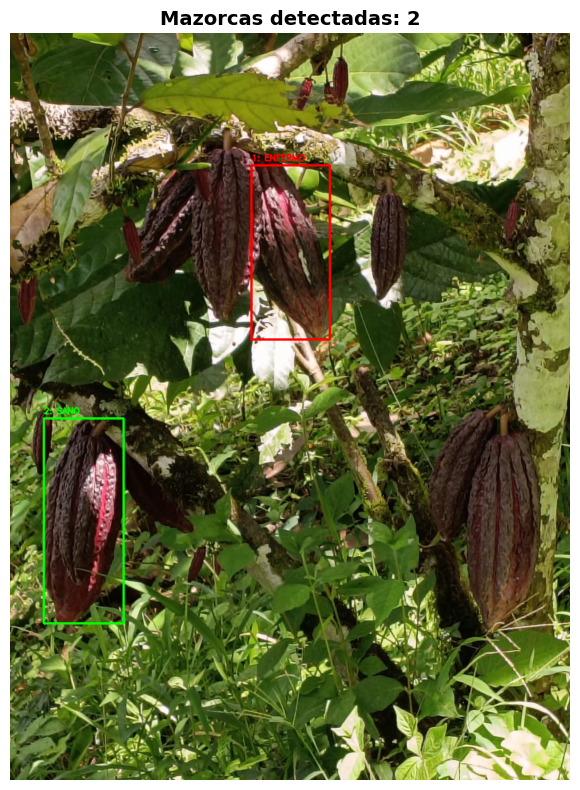

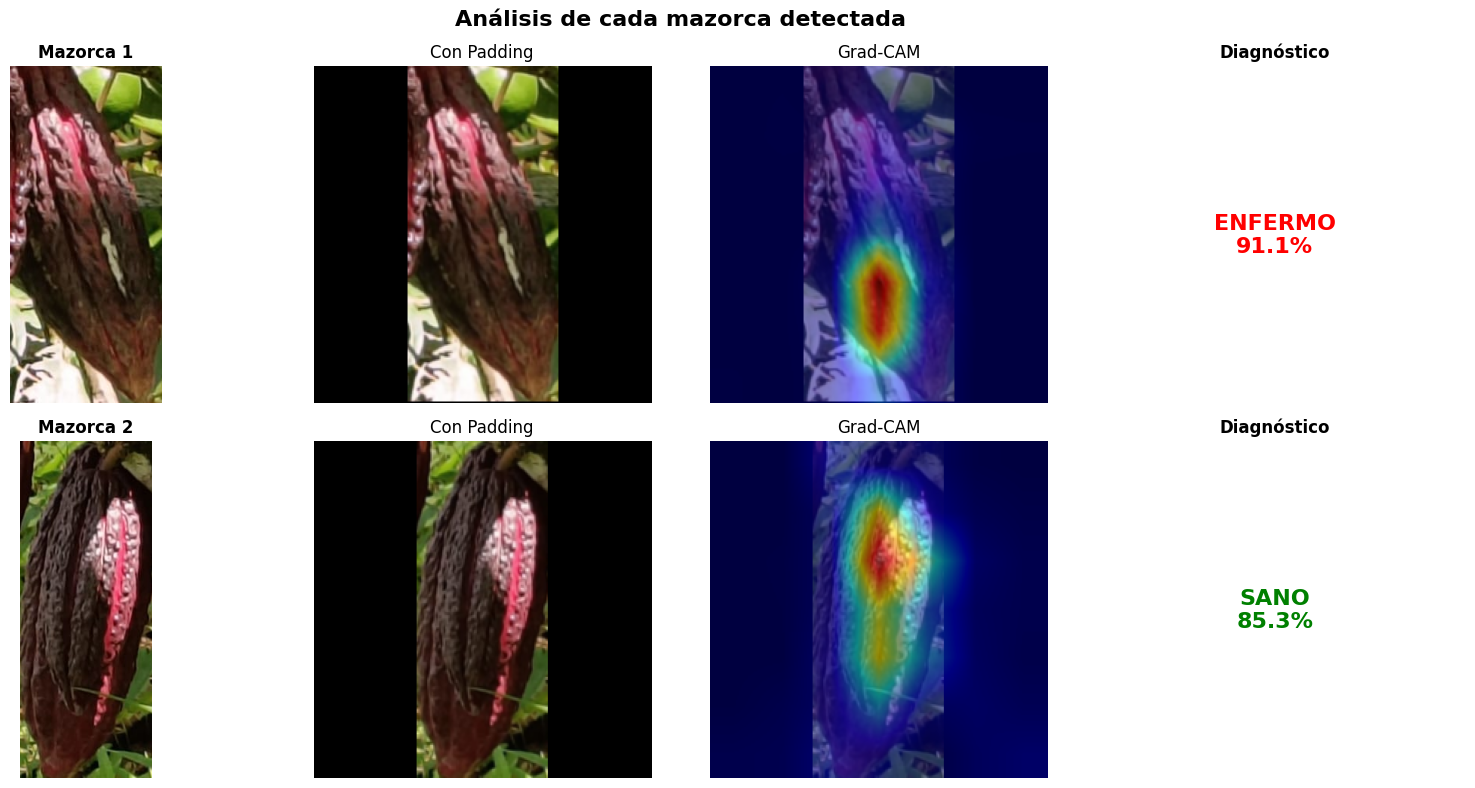


📊 RESUMEN DE DIAGNÓSTICO

🔹 Mazorca 1:
   Diagnóstico: ENFERMO
   Confianza ResNet: 91.06%
   Confianza YOLO: 36.08%

🔹 Mazorca 2:
   Diagnóstico: SANO
   Confianza ResNet: 85.31%
   Confianza YOLO: 34.65%

✅ Proceso completado


In [ ]:
# =====================================================================
# 9. CARGAR IMAGEN DESDE COMPUTADORA LOCAL
# =====================================================================

print("\n" + "="*60)
print("📤 SUBE UNA IMAGEN DESDE TU COMPUTADORA")
print("="*60)
print("Selecciona una imagen de mazorcas de cacao (jpg, jpeg, png)")

# Subir archivo
archivo_subido = files.upload()

# Procesar la primera imagen
for nombre_archivo, contenido in archivo_subido.items():
    # Guardar temporalmente
    ruta_temporal = f"/content/{nombre_archivo}"
    with open(ruta_temporal, 'wb') as f:
        f.write(contenido)

    print(f"\n📸 Procesando: {nombre_archivo}")
    print("="*60)

    # Procesar
    procesar_imagen(ruta_temporal, mostrar_recortes=True)

    # Limpiar
    os.remove(ruta_temporal)
    break

print("\n✅ Proceso completado")

In [ ]:
# =====================================================================
# VERSIÓN 2: EVALUACIÓN COMPLETA DE CASCADA + EXPLICABILIDAD (30 IMÁGENES)
# =====================================================================

import os
import random
import numpy as np
import cv2
import torch
import matplotlib.pyplot as plt
from PIL import Image
from datetime import datetime
from ultralytics import YOLO
from torchvision import transforms

# =====================================================================
# CONFIGURACIÓN
# =====================================================================

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️ Dispositivo: {DEVICE}")

# Rutas (AJUSTA SEGÚN TUS RUTAS)
PATH_YOLO = "/content/drive/MyDrive/TFM_Pipeline/YOLO_Resultados/yolo_exp4-2/weights/best.pt"
PATH_RESNET = "/content/drive/MyDrive/TFM_Pipeline/Pesos_Modelos/exp5_resnet50_cbam_finetuning.pth"
RUTA_TEST = "/content/drive/MyDrive/TFM_Pipeline/Dataset_local/Dataset_60_40_binario/images/test"
OUTPUT_DIR = "/content/drive/MyDrive/TFM_Pipeline/Resultados_Explicabilidad"
NUM_IMAGENES = 91  # <-- CAMBIA AQUÍ EL NÚMERO

os.makedirs(OUTPUT_DIR, exist_ok=True)

# =====================================================================
# CARGAR MODELOS
# =====================================================================

print("📦 Cargando modelos...")
modelo_yolo = YOLO(PATH_YOLO)

# Tu modelo ResNet50+CBAM (ajusta según tu definición)
modelo_resnet = ResNet50_CBAM().to(DEVICE)
modelo_resnet.load_state_dict(torch.load(PATH_RESNET, map_location=DEVICE))
modelo_resnet.eval()

# Transformaciones
resize_padding = ResizeWithPadding(224)
transform_resnet = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])



# =====================================================================
# FUNCIONES DE EXPLICABILIDAD
# =====================================================================

def calcular_iou_con_esporulacion(imagen_rgb, heatmap, umbral_heat=0.4):
    """Calcula IoU entre heatmap y zonas blancas de esporulación"""
    heatmap_uint8 = (heatmap * 255).astype(np.uint8)
    _, mascara_heat = cv2.threshold(heatmap_uint8, int(umbral_heat * 255), 255, cv2.THRESH_BINARY)

    hsv = cv2.cvtColor(imagen_rgb, cv2.COLOR_RGB2HSV)
    mask_blanco = cv2.inRange(hsv, np.array([0, 0, 180]), np.array([180, 50, 255]))
    _, mask_valor_alto = cv2.threshold(hsv[:, :, 2], 200, 255, cv2.THRESH_BINARY)
    mask_blanco = cv2.bitwise_or(mask_blanco, mask_valor_alto)

    interseccion = cv2.bitwise_and(mascara_heat, mask_blanco)
    union = cv2.bitwise_or(mascara_heat, mask_blanco)

    suma_interseccion = np.sum(interseccion > 0)
    suma_union = np.sum(union > 0)

    return suma_interseccion / suma_union if suma_union > 0 else 0.0

def guardar_visualizacion_explicabilidad(resultado, iou, output_dir, idx, es_enfermo):
    """Guarda figura de 4 paneles con IoU"""
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    color = "red" if es_enfermo else "green"
    clase = "ENFERMO" if es_enfermo else "SANO"

    # Panel 1: Original
    axes[0].imshow(resultado['imagen_original'])
    axes[0].set_title(f"1. Original\n{clase}", fontsize=12, fontweight='bold', color=color)
    axes[0].axis('off')

    # Panel 2: Recorte
    axes[1].imshow(resultado['recorte'])
    axes[1].set_title("2. Recorte", fontsize=12, fontweight='bold')
    axes[1].axis('off')

    # Panel 3: Padding + contornos de esporulación
    img_padded = resultado['padded'].copy()
    hsv_pad = cv2.cvtColor(img_padded, cv2.COLOR_RGB2HSV)
    mask_blanco_pad = cv2.inRange(hsv_pad, np.array([0, 0, 180]), np.array([180, 50, 255]))
    contours, _ = cv2.findContours(mask_blanco_pad, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(img_padded, contours, -1, (255, 0, 0), 2)
    axes[2].imshow(img_padded)
    axes[2].set_title("3. Con Padding\n(Borde rojo = esporulación)", fontsize=12, fontweight='bold')
    axes[2].axis('off')

    # Panel 4: Grad-CAM
    axes[3].imshow(resultado['gradcam'])
    axes[3].set_title(f"4. Grad-CAM\nIoU: {iou:.3f}", fontsize=12, fontweight='bold')
    axes[3].axis('off')

    plt.suptitle(f"IoU: {iou:.3f} | {clase} (Conf: {resultado['confianza']:.2f})",
                fontsize=14, fontweight='bold', color=color)
    plt.tight_layout()

    nombre_archivo = os.path.join(output_dir, f"explicabilidad_{idx:03d}.png")
    plt.savefig(nombre_archivo, dpi=300, bbox_inches='tight')
    plt.close(fig)

    return nombre_archivo

def procesar_imagen_cascada(img_path, modelo_yolo, modelo_resnet, resize_padding, transform_resnet, device):
    """Procesa imagen con pipeline YOLO + ResNet y devuelve resultados + GradCAM"""
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        return None

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w, _ = img_bgr.shape

    resultados = modelo_yolo(img_bgr, verbose=False)[0]
    if len(resultados.boxes) == 0:
        return None

    box = resultados.boxes[0]
    x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(w, x2), min(h, y2)

    # Original con bounding box
    img_original = img_rgb.copy()
    cv2.rectangle(img_original, (x1, y1), (x2, y2), (255, 0, 0), 3)

    # Recorte
    recorte = img_rgb[y1:y2, x1:x2]

    # Padding
    pil_recorte = Image.fromarray(recorte)
    img_padded = resize_padding(pil_recorte)
    img_padded_np = np.array(img_padded)

    # Grad-CAM
    input_tensor = transform_resnet(img_padded).unsqueeze(0).to(device)
    grad_cam = GradCAM(modelo_resnet, modelo_resnet.layer4)
    cam, clase_pred, confianza = grad_cam.generar_cam(input_tensor)

    cam_resized = cv2.resize(cam, (img_padded_np.shape[1], img_padded_np.shape[0]))

    # Heatmap superpuesto
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    img_padded_float = img_padded_np.astype(np.float32) / 255.0
    heatmap_float = heatmap.astype(np.float32) / 255.0
    overlay = cv2.addWeighted(img_padded_float, 0.5, heatmap_float, 0.5, 0)

    # Calcular IoU
    iou = calcular_iou_con_esporulacion(img_padded_np, cam_resized)

    return {
        'imagen_original': img_original,
        'recorte': recorte,
        'padded': img_padded_np,
        'gradcam': overlay,
        'clase_pred': clase_pred,
        'confianza': confianza,
        'iou': iou,
        'cam': cam_resized,
        'nombre_archivo': os.path.basename(img_path)
    }

# =====================================================================
# SELECCIONAR IMÁGENES ALEATORIAS
# =====================================================================

print(f"\n📸 Seleccionando {NUM_IMAGENES} imágenes aleatorias...")

imagenes_test = []
for carpeta in ["0_sano", "1_enfermo"]:
    ruta = os.path.join(RUTA_TEST, carpeta)
    if os.path.exists(ruta):
        for archivo in os.listdir(ruta):
            if archivo.endswith(('.jpg', '.jpeg', '.png')):
                # Guardar con etiqueta real (0=sano, 1=enfermo)
                etiqueta = 0 if carpeta == "0_sano" else 1
                imagenes_test.append((os.path.join(ruta, archivo), etiqueta))

# Seleccionar aleatoriamente
if len(imagenes_test) >= NUM_IMAGENES:
    seleccionadas = random.sample(imagenes_test, NUM_IMAGENES)
else:
    seleccionadas = imagenes_test[:min(NUM_IMAGENES, len(imagenes_test))]

print(f"✅ Seleccionadas {len(seleccionadas)} imágenes")

# =====================================================================
# PROCESAR Y EVALUAR
# =====================================================================

resultados_totales = []
iou_por_clase = {'sano': [], 'enfermo': []}
aciertos = 0
total = 0

print(f"\n{'='*70}")
print("PROCESANDO IMÁGENES")
print(f"{'='*70}")

for idx, (img_path, etiqueta_real) in enumerate(seleccionadas):
    print(f"\n[{idx+1}/{len(seleccionadas)}] {os.path.basename(img_path)}")

    resultado = procesar_imagen_cascada(
        img_path, modelo_yolo, modelo_resnet,
        resize_padding, transform_resnet, DEVICE
    )

    if resultado is None:
        print("   ⚠️ No se detectó mazorca")
        continue

    # Determinar si es correcto
    es_correcto = (resultado['clase_pred'] == etiqueta_real)
    if es_correcto:
        aciertos += 1
    total += 1

    # Guardar IoU por clase
    clase_nombre = "enfermo" if etiqueta_real == 1 else "sano"
    iou_por_clase[clase_nombre].append(resultado['iou'])

    # Guardar visualización
    archivo_guardado = guardar_visualizacion_explicabilidad(
        resultado,
        resultado['iou'],
        OUTPUT_DIR,
        idx,
        resultado['clase_pred'] == 1
    )

    resultados_totales.append({
        'archivo': os.path.basename(img_path),
        'real': "ENFERMO" if etiqueta_real == 1 else "SANO",
        'predicho': "ENFERMO" if resultado['clase_pred'] == 1 else "SANO",
        'correcto': es_correcto,
        'confianza': resultado['confianza'],
        'iou': resultado['iou']
    })

    print(f"   Real: {resultados_totales[-1]['real']} | Pred: {resultados_totales[-1]['predicho']}")
    print(f"   IoU: {resultado['iou']:.3f} | Conf: {resultado['confianza']:.2f}")
    print(f"   💾 Guardado: {archivo_guardado}")

# =====================================================================
# ESTADÍSTICAS FINALES
# =====================================================================

print(f"\n{'='*70}")
print("📊 RESULTADOS DE EVALUACIÓN")
print(f"{'='*70}")

accuracy = aciertos / total if total > 0 else 0
iou_promedio = np.mean([r['iou'] for r in resultados_totales]) if resultados_totales else 0
iou_std = np.std([r['iou'] for r in resultados_totales]) if resultados_totales else 0

iou_sano = np.mean(iou_por_clase['sano']) if iou_por_clase['sano'] else 0
iou_enfermo = np.mean(iou_por_clase['enfermo']) if iou_por_clase['enfermo'] else 0

print(f"✅ Accuracy: {accuracy:.4f} ({aciertos}/{total})")
print(f"📊 IoU Promedio (Heatmap vs Esporulación): {iou_promedio:.4f} ± {iou_std:.4f}")
print(f"   - Sano: {iou_sano:.4f} ({len(iou_por_clase['sano'])} imágenes)")
print(f"   - Enfermo: {iou_enfermo:.4f} ({len(iou_por_clase['enfermo'])} imágenes)")

# =====================================================================
# GUARDAR TABLA DE RESULTADOS
# =====================================================================

# Tabla en formato CSV
with open(os.path.join(OUTPUT_DIR, 'tabla_resultados.csv'), 'w') as f:
    f.write("Archivo,Real,Predicho,Correcto,Confianza,IoU\n")
    for r in resultados_totales:
        f.write(f"{r['archivo']},{r['real']},{r['predicho']},{r['correcto']},{r['confianza']:.4f},{r['iou']:.4f}\n")

# Resumen en texto
with open(os.path.join(OUTPUT_DIR, 'resumen_evaluacion.txt'), 'w') as f:
    f.write(f"{'='*70}\n")
    f.write("RESUMEN DE EVALUACIÓN - PIPELINE CASCADA + EXPLICABILIDAD\n")
    f.write(f"{'='*70}\n")
    f.write(f"Fecha: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"Total imágenes evaluadas: {total}\n")
    f.write(f"Accuracy: {accuracy:.4f} ({aciertos}/{total})\n\n")

    f.write("EXPLICABILIDAD (IoU Heatmap vs Esporulación)\n")
    f.write(f"{'-'*50}\n")
    f.write(f"IoU Promedio Global: {iou_promedio:.4f} ± {iou_std:.4f}\n")
    f.write(f"IoU en SANOS: {iou_sano:.4f} (n={len(iou_por_clase['sano'])})\n")
    f.write(f"IoU en ENFERMOS: {iou_enfermo:.4f} (n={len(iou_por_clase['enfermo'])})\n\n")

    f.write("INTERPRETACIÓN\n")
    f.write(f"{'-'*50}\n")
    if iou_enfermo > 0.30:
        f.write("✅ Enfermos: IoU > 0.30 → El modelo capta zonas de esporulación.\n")
    elif iou_enfermo > 0.15:
        f.write("⚠️ Enfermos: IoU 0.15-0.30 → El modelo capta cambios tempranos (textura/brillo).\n")
    else:
        f.write("❌ Enfermos: IoU < 0.15 → El modelo usa otros patrones (forma, tamaño).\n")

    if iou_sano > 0.15:
        f.write("⚠️ Sanos: IoU > 0.15 → Posibles falsas activaciones en frutos sanos.\n")
    else:
        f.write("✅ Sanos: IoU < 0.15 → El modelo no se activa en frutos sanos.\n")

    f.write(f"\n{'='*70}\n")
    f.write("DETALLE POR IMAGEN\n")
    f.write(f"{'='*70}\n")
    f.write(f"{'#':<4} {'Archivo':<30} {'Real':<8} {'Pred':<8} {'Conf':<8} {'IoU':<8}\n")
    f.write(f"{'-'*70}\n")
    for i, r in enumerate(resultados_totales):
        f.write(f"{i+1:<4} {r['archivo'][:30]:<30} {r['real']:<8} {r['predicho']:<8} {r['confianza']:<8.2f} {r['iou']:<8.4f}\n")

print(f"\n📁 Resultados guardados en: {OUTPUT_DIR}")
print(f"   - {len(resultados_totales)} imágenes de explicabilidad")
print(f"   - tabla_resultados.csv")
print(f"   - resumen_evaluacion.txt")

print("\n✅ EVALUACIÓN COMPLETA FINALIZADA")

🖥️ Dispositivo: cuda
📦 Cargando modelos...

📸 Seleccionando 91 imágenes aleatorias...
✅ Seleccionadas 91 imágenes

PROCESANDO IMÁGENES

[1/91] sano_77.jpg
   Real: SANO | Pred: ENFERMO
   IoU: 0.000 | Conf: 0.59
   💾 Guardado: /content/drive/MyDrive/TFM_Pipeline/Resultados_Explicabilidad/explicabilidad_000.png

[2/91] moderado_7.jpeg
   Real: ENFERMO | Pred: ENFERMO
   IoU: 0.000 | Conf: 0.62
   💾 Guardado: /content/drive/MyDrive/TFM_Pipeline/Resultados_Explicabilidad/explicabilidad_001.png

[3/91] moderado_1.jpg
   Real: ENFERMO | Pred: ENFERMO
   IoU: 0.105 | Conf: 0.65
   💾 Guardado: /content/drive/MyDrive/TFM_Pipeline/Resultados_Explicabilidad/explicabilidad_002.png

[4/91] moderado_10.jpeg
   Real: ENFERMO | Pred: ENFERMO
   IoU: 0.091 | Conf: 0.78
   💾 Guardado: /content/drive/MyDrive/TFM_Pipeline/Resultados_Explicabilidad/explicabilidad_003.png

[5/91] sano_82.jpeg
   ⚠️ No se detectó mazorca

[6/91] leve_25.jpg
   Real: ENFERMO | Pred: SANO
   IoU: 0.028 | Conf: 0.98
   💾 Guard